In [3]:
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

In [13]:
IMAGE_DIR = './public_tests/00_test_img_input/train/images/'
GT_CSV_DIR = './public_tests/00_test_img_input/train/gt.csv'

In [115]:
def get_device():
    
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.mps.is_available():
        return torch.device('mps')
    else: 
        return torch.device('cpu')

DEVICE = get_device()
DEVICE

device(type='mps')

In [5]:
def set_seed(seed: int = 78):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

**Starting from baseline**

In [4]:
class BaselineModel(nn.Module):

    def __init__(self, input_size=224):

        super().__init__()

        self.input_size = input_size

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 2))
        )
        
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear( 256 * (input_size // 8) ** 2, 64),
            nn.ReLU(),
            nn.Linear(64, 28)
        )
    
    def forward(self, x):

        x = self.features(x)
        x = self.head(x)

        return x

model = BaselineModel(input_size=224)

In [10]:
class BaselineFacePointsDataset(Dataset):

    def __init__(self, image_dir: str, gt_csv_dir: str = None, image_size: int = 224):

        super().__init__()

        self.image_dir = Path(image_dir)
        self.metadata = pd.read_csv(gt_csv_dir)
        self.image_size = image_size
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):

        if torch.is_tensor(idx):
            idx = idx.item()

        row = self.metadata.iloc[idx]
        image_name = row.loc['filename']
        
        image = Image.open(self.image_dir / image_name).convert('RGB')
        orig_w, orig_h = image.size
        image = image.resize((self.image_size, self.image_size))

        image_array = np.array(image)
        image_array = image_array.astype(np.float32) / 255.0

        image_tensor = torch.from_numpy(image_array).permute(2, 0, 1).float()

        coords = row.iloc[1:].to_numpy(dtype=np.float32)

        x_mult = self.image_size / orig_w
        y_mult = self.image_size / orig_h

        coords[0::2] *= x_mult 
        coords[1::2] *= y_mult

        coords_tensor = torch.from_numpy(coords)
        
        return image_tensor, coords_tensor
        

In [4]:
def get_train_and_val_loaders(
        dataset: Dataset, 
        batch_size: int = 32, 
        val_ratio: float = 0.1, 
        seed: int = 78,
        num_workers: int = 0,
        pin_memory: bool = False):
    
    n = len(dataset)
    val_size = int(n * val_ratio)
    train_size = n - val_size
    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(dataset=dataset, lengths=(train_size, val_size), 
                                    generator=generator)
    train_loader = DataLoader(dataset=train_ds, batch_size=batch_size, shuffle=True, 
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader = DataLoader(dataset=val_ds, batch_size=batch_size, shuffle=False, 
                            num_workers=num_workers, pin_memory=pin_memory)
    
    return train_loader, val_loader

In [ ]:
train_dataset = BaselineFacePointsDataset(
    image_dir=IMAGE_DIR,
    gt_csv_dir=GT_CSV_DIR,
    image_size=224
)

train_loader, val_loader = get_train_and_val_loaders(train_dataset, batch_size=32, val_ratio=0.1)

In [ ]:
def train_model(
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        device: torch.device,
        epochs: int = 20,
        lr: float = 1e-3,
        weight_decay: float = 1e-5,
        save_path: str = './checkpoints/',
        filename: str = 'baseline',
        normalize_targets: bool = False,
        use_amp: bool = False,
        patience: int = 1,
):
    
    current_patience = patience
    save_path = Path(save_path) / (filename + '.pth')
    os.makedirs(save_path.parent, exist_ok=True)

    if device is None:
        device = get_device()
    
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_mse = float('inf')

    for epoch in range(1, epochs + 1):

        model.train()
        train_loss_sum = 0
        train_n = 0
        for images, coords in tqdm(train_loader):
            images = images.to(device=device, dtype=torch.float32)
            coords = coords.to(device=device, dtype=torch.float32)

            if normalize_targets:
                coords / coords / float(images.size(-1))

            preds = model(images)
            loss = criterion(preds, coords)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            train_loss_sum += batch_size * loss.item()
            train_n += batch_size

        train_mse = train_loss_sum / max(1, train_n)

        if val_loader is not None:

            model.eval()

            val_loss_sum = 0
            val_n = 0

            with torch.no_grad():
                for images, coords in val_loader:

                    images = images.to(device=device, dtype=torch.float32)
                    coords = coords.to(device=device, dtype=torch.float32)

                    if normalize_targets:
                        coords /= float(images.size(-1))

                    preds = model(images)
                    loss = criterion(preds, coords)

                    batch_size = images.size(0)
                    val_loss_sum += batch_size * loss.item()
                    val_n += batch_size

                val_mse = val_loss_sum / max(1, train_n)
                print(f'Epoch {epoch:02d}, train mse = {train_mse:.6f}   val mse = {val_mse:.6f}   val rmse = {val_mse ** 0.5:.4f}')

                if val_mse >= best_val_mse:
                    current_patience -= 1
                    if current_patience == 0:
                        print(f'No val MSE decrease, stopping training')
                        return model

                elif save_path is not None:
                    
                    current_patience = patience
                    best_val_mse = val_mse
                    torch.save({'model_state_dict': model.state_dict(),
                                'epoch': epoch,
                                'val_mse': val_mse}, save_path)
                    print(f'Saved best model to {save_path}')

        else:
            print(f'Epoch {epoch:02d}, train mse = {train_mse:.6f}')

    return model

In [9]:
model = train_model(
    model,
    train_loader,
    val_loader,
    DEVICE,
)

100%|██████████| 169/169 [01:06<00:00,  2.53it/s]


Epoch 01, train mse = 680.997151   val mse = 15.300440   val rmse = 3.9116
Saved best model to checkpoints/baseline.pth


100%|██████████| 169/169 [04:35<00:00,  1.63s/it]


Epoch 02, train mse = 158.158024   val mse = 15.057893   val rmse = 3.8805
Saved best model to checkpoints/baseline.pth


100%|██████████| 169/169 [03:39<00:00,  1.30s/it]


Epoch 03, train mse = 140.010562   val mse = 11.953790   val rmse = 3.4574
Saved best model to checkpoints/baseline.pth


100%|██████████| 169/169 [03:10<00:00,  1.13s/it]


Epoch 04, train mse = 114.664409   val mse = 9.316944   val rmse = 3.0524
Saved best model to checkpoints/baseline.pth


  4%|▎         | 6/169 [00:18<08:30,  3.13s/it]


KeyboardInterrupt: 

In [7]:
class FacePointsDataset(Dataset):

    def __init__(
            self, image_dir: str, 
            gt_csv_dir: str = None, 
            image_size: int = 224, 
            return_meta: bool = False
            ):

        super().__init__()

        self.image_dir = Path(image_dir).resolve()
        self.has_coords = gt_csv_dir is not None

        if gt_csv_dir is not None:
            self.metadata = pd.read_csv(gt_csv_dir)
        else:
            # names = sorted([name for name in os.listdir(Path(image_dir).resolve()) \
            #                               if not name.startswith('.')])
            names = sorted([p.name for p in self.image_dir.glob('*.jpg') if p.is_file()])
            self.metadata = pd.DataFrame({'filename': names})

        self.image_size = image_size
        self.return_meta = return_meta
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):

        if torch.is_tensor(idx):
            idx = idx.item()

        row = self.metadata.iloc[idx]
        image_name = row.loc['filename']
        
        image = Image.open(self.image_dir / image_name).convert('RGB')
        orig_w, orig_h = image.size
        image = image.resize((self.image_size, self.image_size))

        image_array = np.array(image)
        image_array = image_array.astype(np.float32) / 255.0

        image_tensor = torch.from_numpy(image_array).permute(2, 0, 1).float()

        coords_tensor = None

        if self.has_coords:
            coords = row.iloc[1:].to_numpy(dtype=np.float32)

            x_mult = self.image_size / orig_w
            y_mult = self.image_size / orig_h

            coords[0::2] *= x_mult 
            coords[1::2] *= y_mult

            coords_tensor = torch.from_numpy(coords)


        if self.return_meta:
            if self.has_coords:
                return image_tensor, coords_tensor, image_name, (orig_w, orig_h)
            else:
                return image_tensor, image_name, (orig_w, orig_h)
        else:
            return image_tensor, coords_tensor


In [ ]:
def detect(
        model_filename: str = None,
        images_path: str = '/Users/nigger/Documents/studying_stuff/9/fall_cv_gml/task_6/public_tests/00_test_img_input/train/images/',
        checkpoint_path: str = '/Users/nigger/Documents/studying_stuff/9/fall_cv_gml/task_6/checkpoints/baseline.pth',
        device: torch.device = None,
        batch_size: int = 16
        ):
    
    images_path = Path(images_path)
    if device == None:
        device = get_device()

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = BaselineModel(input_size=224)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    test_dataset = FacePointsDataset(
        image_dir=images_path,
        gt_csv_dir=None,
        return_meta=True
    )

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    result_dict = {}
    input_size = model.input_size

    with torch.no_grad():
        for batch, image_names, original_shapes in test_loader:
            
            batch = batch.to(device=device, dtype=torch.float32)
            preds = model(batch)
            preds = preds.cpu()

            orig_x = original_shapes[1]
            orig_y = original_shapes[0]
            for pred_tensor, name, x, y in zip(preds, image_names, orig_x, orig_y):

                pred = pred_tensor.clone()
                pred[0::2] *= x / input_size
                pred[1::2] *= y / input_size
                result_dict[name] = pred.tolist()

    return result_dict


In [34]:
res = detect()
res

{'00000.jpg': [54.01027297973633,
  50.14845275878906,
  119.01831817626953,
  56.18712615966797,
  168.53707885742188,
  67.3229751586914,
  220.56631469726562,
  61.476097106933594,
  70.57305908203125,
  66.63040161132812,
  87.7378921508789,
  74.38562774658203,
  111.70874786376953,
  78.1372299194336,
  170.6529541015625,
  87.27906799316406,
  179.36724853515625,
  85.39556884765625,
  205.08807373046875,
  88.86155700683594,
  140.960205078125,
  137.1598358154297,
  84.33677673339844,
  174.23672485351562,
  124.42623138427734,
  185.25140380859375,
  167.53221130371094,
  177.86251831054688],
 '00001.jpg': [19.794157028198242,
  16.75927734375,
  39.419681549072266,
  18.662090301513672,
  56.67656707763672,
  21.39773178100586,
  74.81085205078125,
  22.35729217529297,
  24.190866470336914,
  24.742597579956055,
  31.538707733154297,
  27.020612716674805,
  36.513954162597656,
  27.478172302246094,
  57.669132232666016,
  31.004732131958008,
  64.67344665527344,
  29.6870594

**Baseline done, time for improvements**

**Studying the way face points act when th image is flipped horizontally**

In [8]:
def show_points(idx: int = 0):

    row = pd.read_csv('../task_6/public_tests/00_test_img_input/train/gt.csv').iloc[idx]
    name = row.loc['filename']
    x_coords = row.iloc[1::2].values
    y_coords = row.iloc[2::2].values
    image_array = np.array(Image.open('../task_6/public_tests/00_test_img_input/train/images/' + name))
    plt.figure()
    plt.imshow(image_array)
    for i in range(len(x_coords)):
        plt.scatter(x_coords[i], y_coords[i], label=f'{i}')
    plt.legend()
    plt.show()

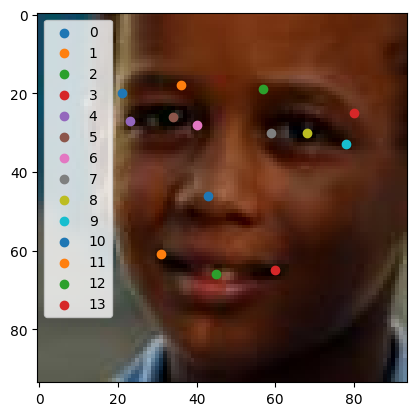

In [ ]:
show_points(1)

In [ ]:
def flip_coordinates(coords: np.array) -> np.array:

    coords[:] = coords[[6, 7, 4, 5, 2, 3, 0, 1, 18, 19, 16, 17, 14, 15, \
                        12, 13, 10, 11, 8, 9, 20, 21, 26, 27, 24, 25, 22, 23]]

In [ ]:
coords = np.array([51,51,127,60,169,65,203,52,68,77,85,75,110,82,160,87,171,79,193,84,156,144,92,174,140,180,168,179])
flip_coordinates(coords)
coords

array([203,  52, 169,  65, 127,  60,  51,  51, 193,  84, 171,  79, 160,
        87, 110,  82,  85,  75,  68,  77, 156, 144, 168, 179, 140, 180,
        92, 174])

**Using better architectire**(no more 13m FC)

In [8]:
class BetterModel(nn.Module):

    def __init__(self, input_size=224):

        super().__init__()

        self.input_size = input_size

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.AdaptiveAvgPool2d(4)
        )
        
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 28)
        )
    
    def forward(self, x):

        x = self.features(x)
        x = self.head(x)

        return x

better_model = BetterModel(input_size=224)

In [ ]:
train_dataset = FacePointsDataset(
    image_dir=IMAGE_DIR,
    gt_csv_dir=GT_CSV_DIR,
    image_size=224
)

train_loader, val_loader = get_train_and_val_loaders(train_dataset, batch_size=16, val_ratio=0.1)

In [9]:
def load_from_state_dict(model, filename):
    model.load_state_dict(torch.load(f'./checkpoints/{filename}.pth', map_location=torch.device(DEVICE))['model_state_dict'])

In [34]:
better_model_checkpoint = BetterModel()
load_from_state_dict(better_model_checkpoint, 'better_model')

In [36]:
better_model = train_model(
    better_model_checkpoint,
    train_loader,
    val_loader,
    DEVICE,
    epochs=40,
    lr=3e-4,
    patience=5,
    filename='better_model'
)

100%|██████████| 338/338 [01:15<00:00,  4.47it/s]


Epoch 01, train mse = 98.328786   val mse = 6.865179   val rmse = 2.6201
Saved best model to checkpoints/better_model.pth


100%|██████████| 338/338 [01:09<00:00,  4.85it/s]


Epoch 02, train mse = 98.025135   val mse = 6.947518   val rmse = 2.6358


100%|██████████| 338/338 [01:08<00:00,  4.92it/s]


...

Epoch 31, train mse = 78.861879   val mse = 6.633535   val rmse = 2.5756


100%|██████████| 338/338 [01:15<00:00,  4.49it/s]


Epoch 32, train mse = 79.424294   val mse = 6.541921   val rmse = 2.5577


100%|██████████| 338/338 [01:15<00:00,  4.47it/s]


Epoch 33, train mse = 77.365817   val mse = 5.801704   val rmse = 2.4087
No val MSE decrease, stopping training


**Time to add augmentations**

In [37]:
!python3 -m pip install albumentations

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 11.9 MB/s eta 0:00:0000:0100:01
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
Using cached pydantic_core-2.41.5-cp312-cp312-macosx_11_0_arm64.whl (1.9 MB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade 

In [45]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

facepoints_transforms = A.Compose([
    # A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.05,
        rotate_limit=10,
        p=0.5
    ),
],
keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)
)


/Users/nigger/Documents/studying_stuff/9/fall_cv_gml/CVenv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


We need to flip coordinates(change order) if using horizontal flip

In [ ]:
def flip_coordinates(coords: np.array) -> np.array:

    coords[:] = coords[[6, 7, 4, 5, 2, 3, 0, 1, 18, 19, 16, 17, 14, 15, \
                        12, 13, 10, 11, 8, 9, 20, 21, 26, 27, 24, 25, 22, 23]]

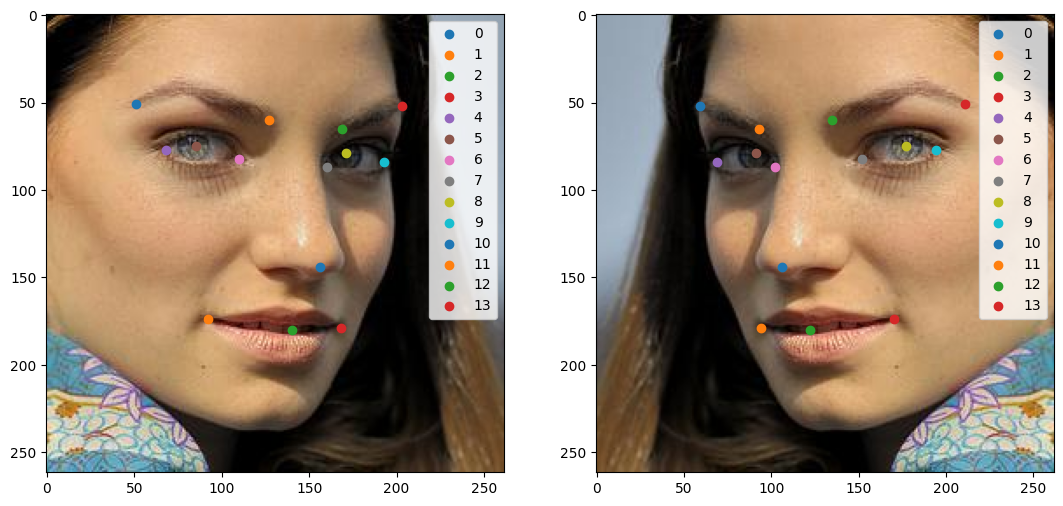

In [ ]:
image = Image.open(IMAGE_DIR + '00000.jpg')
coords = pd.read_csv(GT_CSV_DIR).iloc[0, 1:].values
coords = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]

fig, axs = plt.subplots(1, 2, figsize=(13, 7))
axs[0].imshow(image)
for i, (x, y) in enumerate(coords):
    axs[0].scatter(x, y, label=f'{i}')
axs[0].legend()
    
test_transforms = A.Compose([A.HorizontalFlip(p=1)], keypoint_params=A.KeypointParams(format='xy'))

coords = np.array(coords)
image_array = np.ascontiguousarray(np.array(image)[:, ::-1])
coords[:, 0] = image_array.shape[1] - coords[:, 0]
coords = coords.flatten()
flip_coordinates(coords)
coords = [(coords[i], coords[i+1]) for i in range(0, len(coords), 2)]

axs[1].imshow(image_array)
for i, (x, y) in enumerate(coords):
    axs[1].scatter(x, y, label=f'{i}')
axs[1].legend()


In [ ]:
class FacePointsTransformDataset(Dataset):

    def __init__(
            self, image_dir: str, 
            gt_csv_dir: str = None,
            gt_df: pd.DataFrame = None, 
            image_size: int = 224, 
            transforms: A.Compose = None,
            flip_prob: float = 0.5,
            return_meta: bool = False
            ):

        super().__init__()

        self.image_dir = Path(image_dir).resolve()
        self.has_coords = (gt_csv_dir is not None) or (gt_df is not None)

        if gt_df is not None:
            self.metadata = gt_df
        elif gt_csv_dir is not None:
            self.metadata = pd.read_csv(gt_csv_dir)
        else:
            names = sorted([p.name for p in self.image_dir.glob('*.jpg') if p.is_file()])
            self.metadata = pd.DataFrame({'filename': names})

        self.image_size = image_size
        self.transforms = transforms
        self.flip_prob = flip_prob
        self.return_meta = return_meta
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):

        if torch.is_tensor(idx):
            idx = idx.item()

        row = self.metadata.iloc[idx]
        image_name = row.loc['filename']
        
        image = Image.open(self.image_dir / image_name).convert('RGB')
        orig_w, orig_h = image.size

        image_array = np.array(image)
        image_array = image_array.astype(np.float32) / 255.0

        coords_tensor = None

        if self.has_coords:

            coords = row.iloc[1:].to_numpy(dtype=np.float32)

            if self.transforms:

                if np.random.rand() < self.flip_prob:
                    
                    image_array = np.ascontiguousarray(image_array[:, ::-1])
                    coords[0::2] = image_array.shape[1] - coords[0::2]
                    flip_coordinates(coords)
                
                keypoints = [(coords[i], coords[i + 1]) for i in range(0, len(coords), 2)]
                augmented = self.transforms(image=image_array, keypoints=keypoints)
                
                image_array = augmented['image']

                keypoints = augmented['keypoints']

                aug_coords = []
                for x, y in keypoints:
                    aug_coords.extend([x, y])

                coords = np.array(aug_coords)

            x_mult = self.image_size / orig_w
            y_mult = self.image_size / orig_h

            coords[0::2] *= x_mult 
            coords[1::2] *= y_mult

            coords_tensor = torch.from_numpy(np.array(coords, dtype=np.float32))

        image_array = cv2.resize(
            image_array, 
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR
            )
        image_tensor = torch.from_numpy(image_array).permute(2, 0, 1).float()
        

        if self.return_meta:
            if self.has_coords:
                return image_tensor, coords_tensor, image_name, (orig_w, orig_h)
            else:
                return image_tensor, image_name, (orig_w, orig_h)
        else:
            return image_tensor, coords_tensor


In [85]:
from sklearn.model_selection import train_test_split

metadata = pd.read_csv(GT_CSV_DIR)
train_metadata, val_metadata = train_test_split(metadata, test_size=0.1, random_state=78)
train_metadata.reset_index(drop=True, inplace=True)
val_metadata.reset_index(drop=True, inplace=True)

In [101]:
train_dataset = FacePointsTransformDataset(
    image_dir=IMAGE_DIR,
    gt_df=train_metadata,
    transforms=facepoints_transforms
)

val_dataset = FacePointsTransformDataset(
    image_dir=IMAGE_DIR,
    gt_df=val_metadata
)

train_aug_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_no_aug_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [72]:
best_model_checkpoint = BetterModel()
load_from_state_dict(best_model_checkpoint, 'best_model_5_58')

In [76]:
best_model = train_model(
    best_model_checkpoint,
    train_aug_loader,
    val_no_aug_loader,
    DEVICE,
    epochs=200,
    lr=3e-4,
    patience=20,
    filename='better_model'
)

100%|██████████| 338/338 [01:13<00:00,  4.62it/s]


Epoch 01, train mse = 185.756193   val mse = 12.527663   val rmse = 3.5394
Saved best model to checkpoints/better_model.pth


100%|██████████| 338/338 [01:12<00:00,  4.68it/s]


Epoch 02, train mse = 181.328355   val mse = 12.201479   val rmse = 3.4931
Saved best model to checkpoints/better_model.pth


100%|██████████| 338/338 [01:16<00:00,  4.44it/s]


...

Epoch 20, train mse = 166.702846   val mse = 12.798951   val rmse = 3.5776


100%|██████████| 338/338 [01:19<00:00,  4.23it/s]


Epoch 21, train mse = 166.876635   val mse = 13.733601   val rmse = 3.7059


100%|██████████| 338/338 [01:22<00:00,  4.12it/s]


Epoch 22, train mse = 165.308187   val mse = 13.617818   val rmse = 3.6902
No val MSE decrease, stopping training


**Runnung and editting these cell with in cycle to finish training**

In [ ]:
torch.save({'model_state_dict': best_model.state_dict(),
            'epoch': 143,
            'val_mse': 4.984075}, './checkpoints/?.pth')

In [113]:
current_model = BetterModel()
load_from_state_dict(current_model, 'best_model_5_09')

In [114]:
best_model = train_model(
    current_model,
    train_aug_loader,
    val_no_aug_loader,
    DEVICE,
    epochs=200,
    lr=1e-5,
    patience=20,
    filename='better_model'
)

100%|██████████| 338/338 [01:25<00:00,  3.97it/s]


Epoch 01, train mse = 156.694280   val mse = 11.687282   val rmse = 3.4187
Saved best model to checkpoints/better_model.pth


  4%|▍         | 13/338 [00:03<01:36,  3.37it/s]


KeyboardInterrupt: 